Cargar librerías y dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Cargar dataset limpio
df = pd.read_excel("C:/Users/Vìctor/OneDrive/Desktop/ESP_Project/EDA/df_final_curado.xlsx")


# Asegurar formato de fecha
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(f"Registros: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head(20)


Registros: 14133, Columnas: 20


,Date,PRUEBA_DE_PRODUCCION_PETROLEO_A_24_HORAS_bbl/d,PRUEBA_DE_PRODUCCION_AGUA_A_24_HORAS_bbl/d,Prueba_pozo.Oil_24_+_Prueba_pozo.Water_24,PRUEBA_DE_PRODUCCION_GAS_A_24_HORAS_Mcf/d,BSW___%,GRAVEDAD_API_DEL_PETROLEO,SALINIDAD___PPM_PU,PRESION_DE_INTAKE_psi,FRECUENCIA_BOMBA_Hz,AMPERAJE_BOMBA_Amp,PRESION_DE_TUBING_psi,PRESION_DE_CASING_psi,TIPO_DE_BOMBA,TEMPERATURA_DE_LA_BOMBA_Deg._F,ETAPAS_DE_LA_BOMBA,POZO,CAMPO,completitud_%,Fecha_inicio_valida
0,2017-01-20,141.0,364.0,505.0,28.62,72.08,22.1,10200.0,973.0,60.0,46.0,50.0,NaN,TD1000,NaN,266.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
1,2017-02-09,166.0,427.0,593.0,9.44,72.01,22.1,10200.0,894.0,50.0,29.0,60.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
2,2017-03-01,153.0,395.0,548.0,31.06,72.08,22.1,NaN,NaN,NaN,NaN,50.0,NaN,TD1000,NaN,NaN,SCH-018UI,SACHA CENTRAL,50.000000,2017-01-20
3,2017-03-07,92.0,370.0,462.0,9.44,80.09,22.1,10200.0,914.0,48.0,27.0,80.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
4,2017-03-10,178.0,459.0,637.0,9.44,72.06,22.1,10200.0,875.0,51.0,31.0,75.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
5,2017-04-11,176.0,452.0,628.0,9.44,71.97,22.1,10200.0,871.0,51.0,31.0,80.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
6,2017-04-12,192.0,494.0,686.0,9.44,72.01,22.1,10200.0,851.0,53.0,32.0,90.0,NaN,TD1000QPLUS/TD1000QPLUS/TD1000QPLUS,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
7,2017-04-29,118.0,474.0,592.0,9.44,80.07,22.1,10200.0,917.0,47.0,29.0,40.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
8,2017-05-01,146.0,375.0,521.0,29.64,71.98,22.1,NaN,NaN,NaN,NaN,50.0,NaN,TD1000,NaN,NaN,SCH-018UI,SACHA CENTRAL,50.000000,2017-01-20
9,2017-06-02,141.0,364.0,505.0,9.44,72.08,22.1,10200.0,973.0,60.0,46.0,50.0,NaN,TD1000,NaN,266.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20


Completitud general y por campo

Completitud general (%):
 PRESION_DE_INTAKE_psi                              77.46
FRECUENCIA_BOMBA_Hz                                94.73
AMPERAJE_BOMBA_Amp                                 93.91
BSW___%                                            99.96
PRUEBA_DE_PRODUCCION_PETROLEO_A_24_HORAS_bbl/d    100.00
dtype: float64


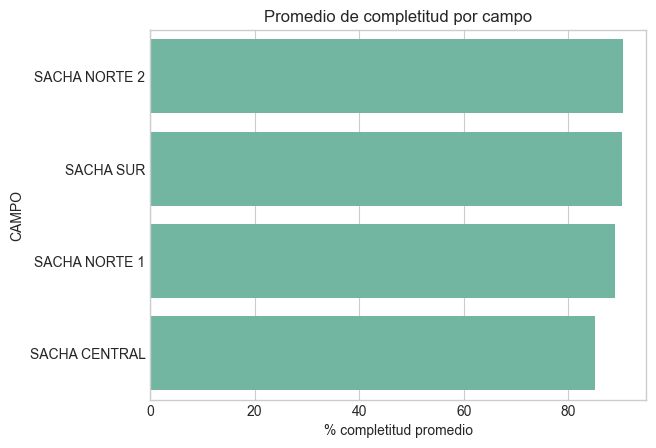

In [6]:
# Completitud general
completitud_global = df[[
    'PRESION_DE_INTAKE_psi', 'FRECUENCIA_BOMBA_Hz', 'AMPERAJE_BOMBA_Amp',
    'BSW___%', 'PRUEBA_DE_PRODUCCION_PETROLEO_A_24_HORAS_bbl/d'
]].notna().mean() * 100

print("Completitud general (%):\n", completitud_global.round(2))

# Completitud promedio por campo
completitud_campo = df.groupby("CAMPO")["completitud_%"].mean().sort_values(ascending=False)
sns.barplot(x=completitud_campo.values, y=completitud_campo.index)
plt.title("Promedio de completitud por campo")
plt.xlabel("% completitud promedio")
plt.show()


Distribución de variables clave por campo

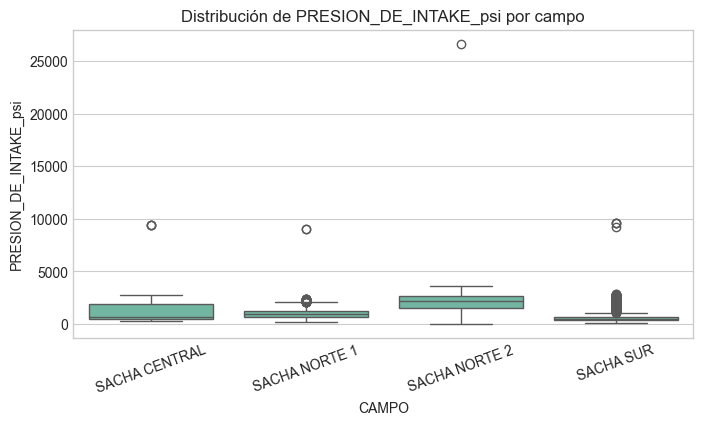

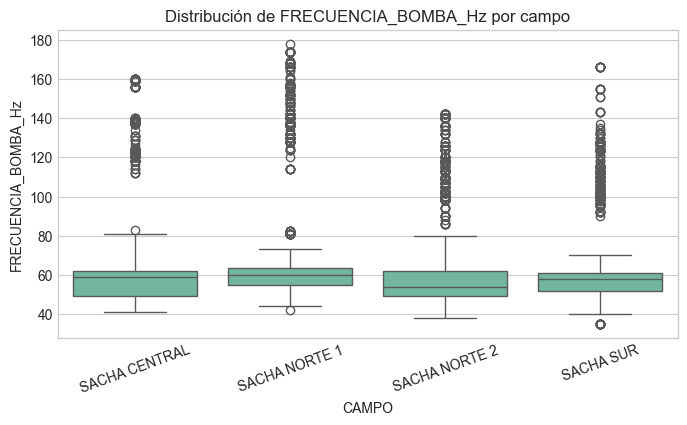

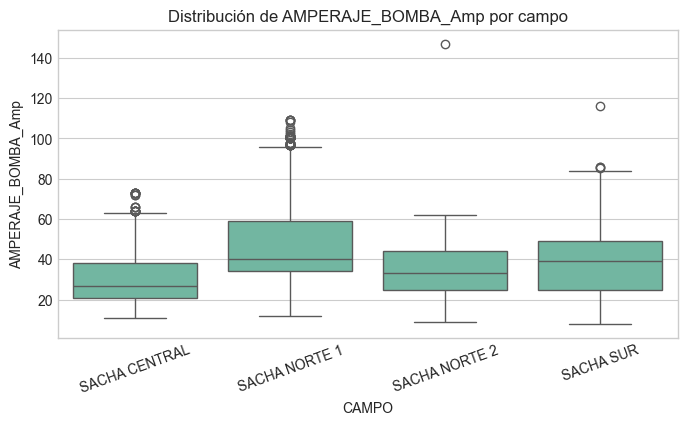

In [7]:
variables = ['PRESION_DE_INTAKE_psi', 'FRECUENCIA_BOMBA_Hz', 'AMPERAJE_BOMBA_Amp']

for var in variables:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='CAMPO', y=var)
    plt.title(f"Distribución de {var} por campo")
    plt.xticks(rotation=20)
    plt.show()


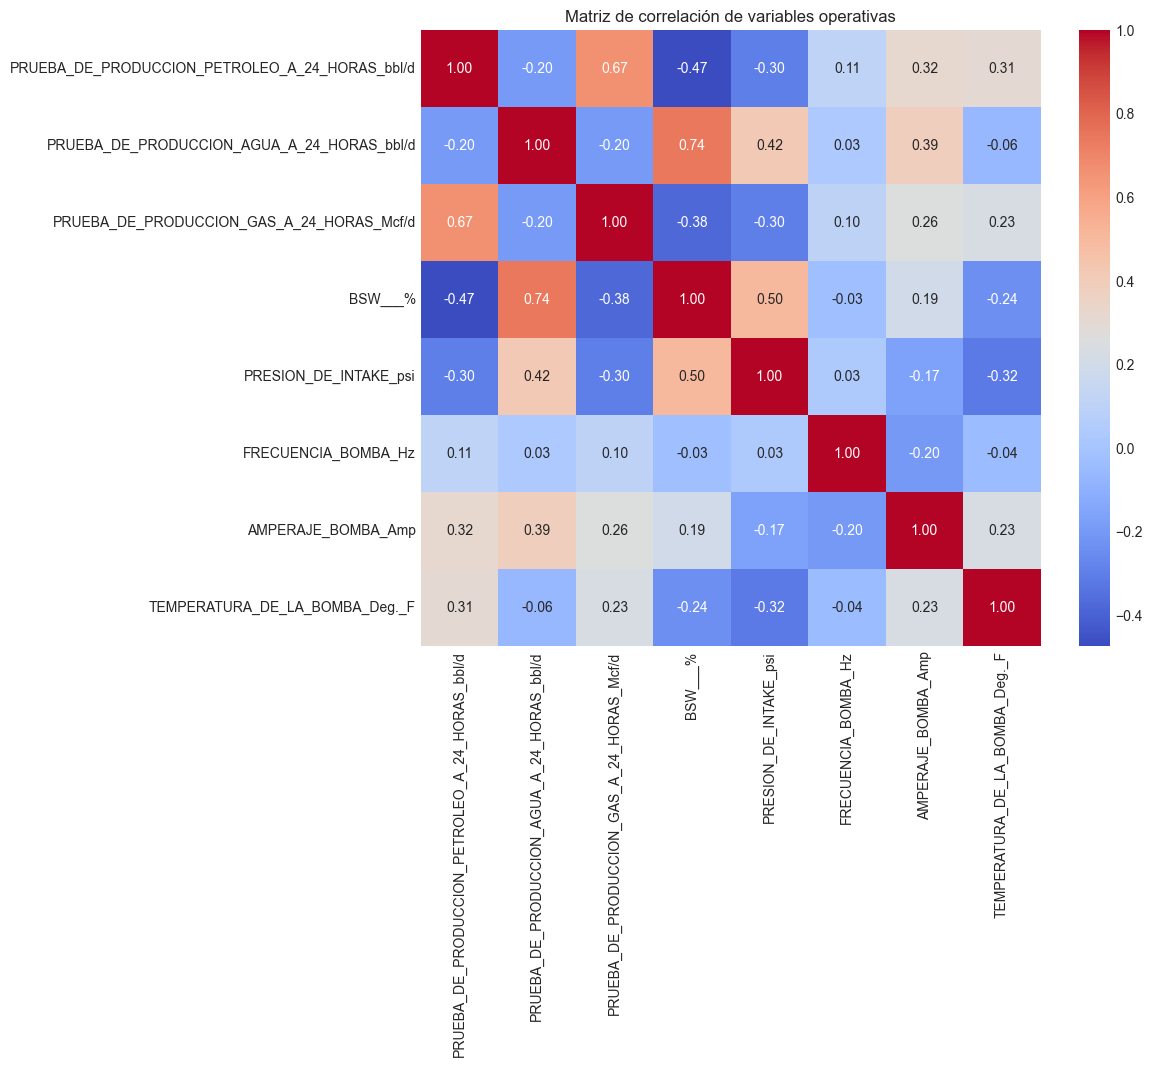

In [8]:
corr_vars = [
    'PRUEBA_DE_PRODUCCION_PETROLEO_A_24_HORAS_bbl/d',
    'PRUEBA_DE_PRODUCCION_AGUA_A_24_HORAS_bbl/d',
    'PRUEBA_DE_PRODUCCION_GAS_A_24_HORAS_Mcf/d',
    'BSW___%', 'PRESION_DE_INTAKE_psi', 'FRECUENCIA_BOMBA_Hz', 
    'AMPERAJE_BOMBA_Amp', 'TEMPERATURA_DE_LA_BOMBA_Deg._F'
]

corr = df[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación de variables operativas")
plt.show()


Evolución temporal de variables críticas por campo

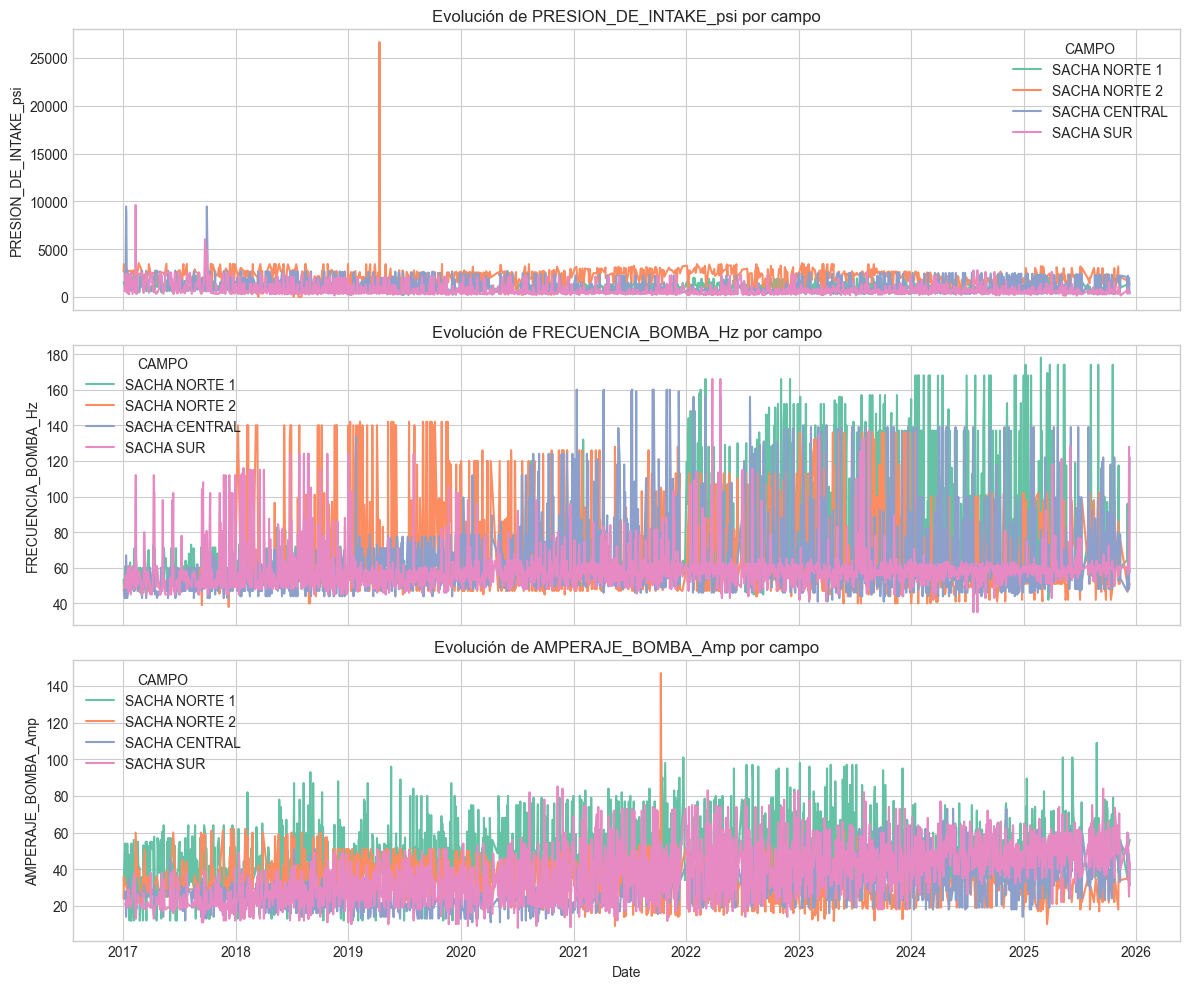

In [9]:
# Promedio diario por campo
df_campo = df.groupby(["Date","CAMPO"])[["PRESION_DE_INTAKE_psi","FRECUENCIA_BOMBA_Hz","AMPERAJE_BOMBA_Amp"]].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)
for i, var in enumerate(["PRESION_DE_INTAKE_psi","FRECUENCIA_BOMBA_Hz","AMPERAJE_BOMBA_Amp"]):
    sns.lineplot(ax=axes[i], data=df_campo, x="Date", y=var, hue="CAMPO")
    axes[i].set_title(f"Evolución de {var} por campo")
plt.tight_layout()
plt.show()


Detección visual de outliers

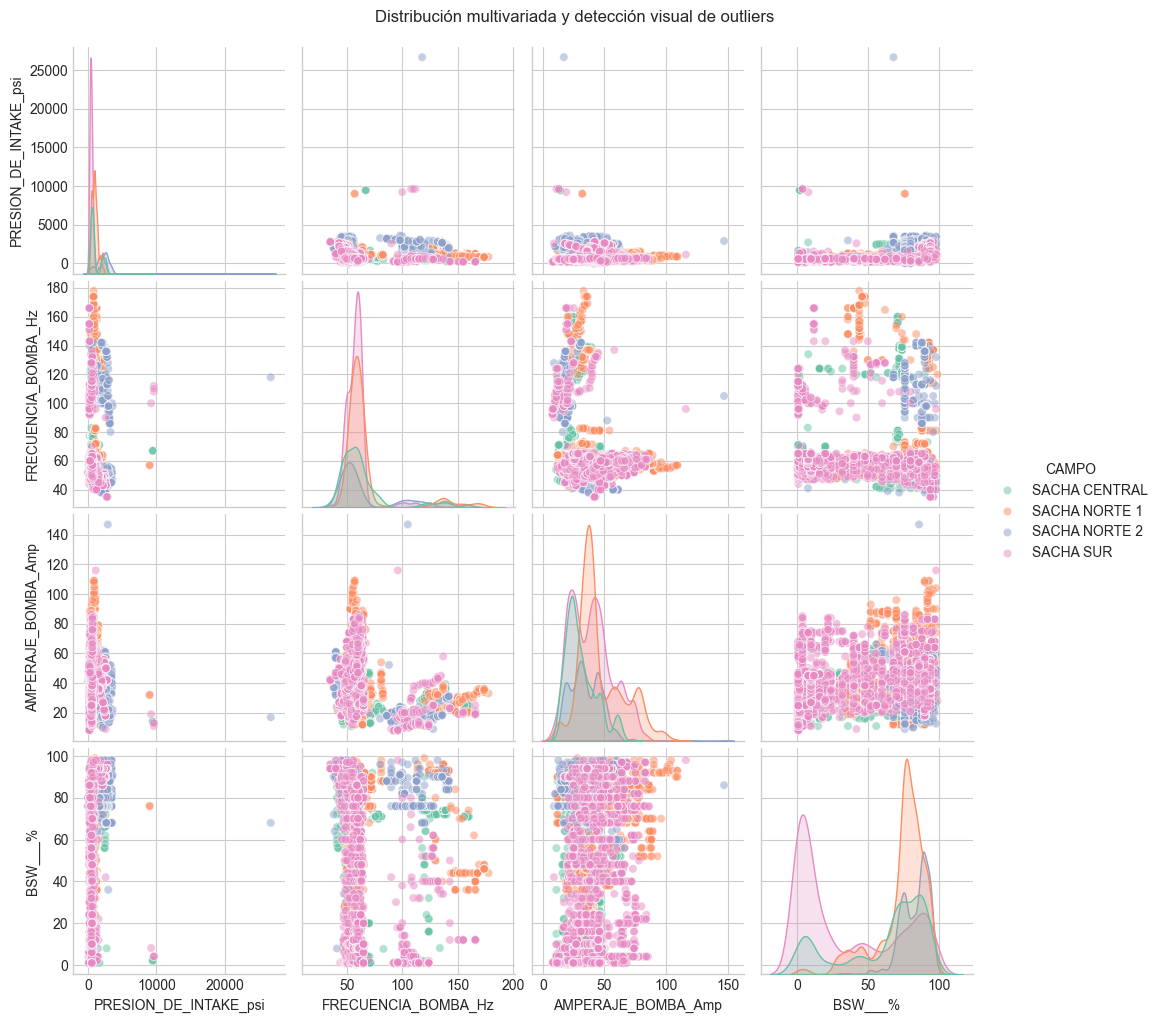

In [10]:
sns.pairplot(df, vars=['PRESION_DE_INTAKE_psi','FRECUENCIA_BOMBA_Hz','AMPERAJE_BOMBA_Amp','BSW___%'], 
             hue='CAMPO', plot_kws={'alpha':0.5})
plt.suptitle("Distribución multivariada y detección visual de outliers", y=1.02)
plt.show()


Identificar patrones de cambios de bomba

In [11]:
df = pd.read_excel("C:/Users/Vìctor/OneDrive/Desktop/ESP_Project/EDA/df_final_curado.xlsx")


In [12]:
import pandas as pd, numpy as np, re

df = df.sort_values(["POZO","Date"]).reset_index(drop=True)

# --- 1) Canonizar tipo/etapas ---
def canon_tipo(s):
    if pd.isna(s): return np.nan
    s = str(s).upper().strip()
    s = re.sub(r"\s+", "", s)
    s = s.replace("-", "").replace("_","")
    return s if s not in {"", "NA", "NAN"} else np.nan

def canon_etapas(x):
    try:
        v = pd.to_numeric(str(x).strip(), errors="coerce")
        return pd.array(v, dtype="Int64")
    except Exception:
        return pd.array([pd.NA], dtype="Int64")[0]

df["TIPO_clean"]   = df["TIPO_DE_BOMBA"].map(canon_tipo)
df["ETAPAS_clean"] = df["ETAPAS_DE_LA_BOMBA"].map(canon_etapas)

# ffill/bfill por pozo para evitar NaN intermitentes
df[["TIPO_clean","ETAPAS_clean"]] = (
    df.groupby("POZO")[["TIPO_clean","ETAPAS_clean"]]
      .apply(lambda g: g.ffill().bfill())
      .reset_index(level=0, drop=True)
)

# --- 2) Hash limpio y cambio bruto ---
df["hash_clean"] = df["TIPO_clean"].astype(str) + "|" + df["ETAPAS_clean"].astype(str)
prev_hash = df.groupby("POZO")["hash_clean"].shift()
df["chg_raw"] = (df["hash_clean"] != prev_hash).astype(int)
# el primer registro del pozo NO lo contamos como cambio
df.loc[df.groupby("POZO").head(1).index, "chg_raw"] = 0

# --- 3) Persistencia mínima del NUEVO estado ---
# run_id bruto y duración por run (en filas y en días)
df["run_id_raw"] = df.groupby("POZO")["chg_raw"].cumsum() + 1
gsize = df.groupby(["POZO","run_id_raw"]).size().rename("dur_rows")
gstart = df.groupby(["POZO","run_id_raw"])["Date"].min().rename("start")
gend   = df.groupby(["POZO","run_id_raw"])["Date"].max().rename("end")
runs = pd.concat([gsize, gstart, gend], axis=1).reset_index()
runs["dur_days"] = (runs["end"] - runs["start"]).dt.days + 1

# umbrales (ajusta a tu granularidad)
k_rows, k_days = 3, 3
valid_runs = runs[(runs["dur_rows"] >= k_rows) & (runs["dur_days"] >= k_days)]

# marcaremos como "cambio válido" el INICIO de cada run válido (excepto run 1)
valid_starts = valid_runs[valid_runs["run_id_raw"] > 1][["POZO","run_id_raw","start"]]
valid_starts = valid_starts.rename(columns={"start":"fecha_cambio"})
valid_starts["key"] = valid_starts["POZO"].astype(str) + "|" + valid_starts["run_id_raw"].astype(str)

# --- 4) Extraer tripletas usando POSICIÓN dentro de cada pozo ---
tripletas = []
conteo = []

for pozo, g in df.groupby("POZO", sort=False):
    g = g.sort_values("Date").reset_index(drop=False).rename(columns={"index":"idx_global"})
    # runs válidos de este pozo
    vr = valid_starts[valid_starts["POZO"] == pozo]
    conteo.append({"POZO": pozo, "n_cambios_bomba_validos": len(vr)})

    for _, ev in vr.iterrows():
        rid = ev["run_id_raw"]
        fecha_cambio = ev["fecha_cambio"]

        # ubicar la primera fila del run_id_raw actual (cambio) en g
        # tomamos la fila cuya Date == fecha_cambio (o la más próxima posterior)
        pos_cambio = g.index[g["Date"] == fecha_cambio]
        if len(pos_cambio) == 0:
            pos_cambio = g[g["Date"] > fecha_cambio].index[:1]
            if len(pos_cambio) == 0: 
                continue
        p = int(pos_cambio[0])

        prev_p = max(p-1, 0)
        next_p = min(p+1, len(g)-1)

        filas = [("before", g.loc[prev_p]), ("change", g.loc[p]), ("after", g.loc[next_p])]

        # seguridad: exigir que el hash_clean realmente cambie entre before y change
        if filas[0][1]["hash_clean"] == filas[1][1]["hash_clean"]:
            continue

        event_id = f"{pozo}|run{rid}|{pd.to_datetime(fecha_cambio).date()}"
        for etiqueta, row in filas:
            d = row.to_dict()
            d.update({"etiqueta": etiqueta, "event_id": event_id})
            tripletas.append(d)

tripletas_df = pd.DataFrame(tripletas)

# --- 5) Selección de columnas útiles y orden ---
cols_mostrar = [
    "POZO","Date","etiqueta","event_id",
    "TIPO_DE_BOMBA","ETAPAS_DE_LA_BOMBA","TIPO_clean","ETAPAS_clean","hash_clean",
    "PRESION_DE_INTAKE_psi","FRECUENCIA_BOMBA_Hz","AMPERAJE_BOMBA_Amp","CAMPO"
]
tripletas_vista = (tripletas_df[cols_mostrar]
                   .sort_values(["POZO","event_id","Date","etiqueta"])
                   .reset_index(drop=True))

conteo_cambios_validos = pd.DataFrame(conteo).sort_values("n_cambios_bomba_validos", ascending=False)

print("▶️ Conteo de cambios válidos por pozo (persis ≥", k_rows, "filas y ≥", k_days, "días):")
print(conteo_cambios_validos.head(20), "\n")

print("▶️ Tripletas (antes/cambio/después) — muestra")
print(tripletas_vista.head(12))


▶️ Conteo de cambios válidos por pozo (persis ≥ 3 filas y ≥ 3 días):
             POZO  n_cambios_bomba_validos
5        SCH-088T                       42
4       SCH-087BT                       34
8       SCH-124UI                       33
11       SCH-134U                       30
31   SCHAO-478HUI                       27
25    SCHAJ-428TI                       26
7       SCH-123UI                       24
17    SCHAB-316UI                       24
0        SCH-007U                       23
40     SCHP-181UI                       23
27  SCHAO-471R1TI                       23
6       SCH-106HS                       23
1       SCH-018UI                       23
13      SCH-186UI                       21
30   SCHAO-477HUI                       21
45     SCHV-227HS                       20
26    SCHAM-452HI                       20
29   SCHAO-475HUI                       18
12      SCH-142UI                       17
39     SCHH-239HS                       17 

▶️ Tripletas (antes/cambio

Ver filas de antes y despues de cambio de bomba 

In [14]:
import pandas as pd

# 1) Evitar truncado en pantalla
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)                 # usa ancho dinámico
pd.set_option("display.max_colwidth", None)

# 2) Verifica que existan las columnas clave
print("Cols tripletas_vista:", list(tripletas_vista.columns))

# 3) Orden fijo de etiquetas para que salgan en el orden correcto
orden = pd.CategoricalDtype(categories=["before","change","after"], ordered=True)
tripletas_vista["etiqueta"] = tripletas_vista["etiqueta"].astype(orden)

# 4) Muestra limpia de las columnas relevantes (sin truncado)
cols = [
    "POZO","Date","etiqueta","event_id",
    "TIPO_DE_BOMBA","ETAPAS_DE_LA_BOMBA","TIPO_clean","ETAPAS_clean","hash_clean",
    "PRESION_DE_INTAKE_psi","FRECUENCIA_BOMBA_Hz","AMPERAJE_BOMBA_Amp","CAMPO"
]
print("\n▶️ Tripletas (primeras 12 filas):")
print(tripletas_vista[cols].sort_values(["POZO","event_id","Date","etiqueta"]).head(12).to_string(index=False))


Cols tripletas_vista: ['POZO', 'Date', 'etiqueta', 'event_id', 'TIPO_DE_BOMBA', 'ETAPAS_DE_LA_BOMBA', 'TIPO_clean', 'ETAPAS_clean', 'hash_clean', 'PRESION_DE_INTAKE_psi', 'FRECUENCIA_BOMBA_Hz', 'AMPERAJE_BOMBA_Amp', 'CAMPO']

▶️ Tripletas (primeras 12 filas):
    POZO       Date etiqueta                  event_id              TIPO_DE_BOMBA  ETAPAS_DE_LA_BOMBA                 TIPO_clean  ETAPAS_clean                     hash_clean  PRESION_DE_INTAKE_psi  FRECUENCIA_BOMBA_Hz  AMPERAJE_BOMBA_Amp         CAMPO
SCH-007U 2017-09-05   before SCH-007U|run10|2017-09-09                        NaN                 0.0              TD1000/TD1000           NaN              TD1000/TD1000|nan                 1037.0                 60.0                25.0 SACHA NORTE 1
SCH-007U 2017-09-09   change SCH-007U|run10|2017-09-09 WD1000MF/WD1000MF/WD1000MF               352.0 WD1000MF/WD1000MF/WD1000MF           NaN WD1000MF/WD1000MF/WD1000MF|nan                 1068.0                 47.0                22.

Normalización robusto para TIPO_DE_BOMBA (y ETAPAS_DE_LA_BOMBA)

In [18]:
import re
import pandas as pd
import numpy as np

# ========= Helpers =========
def _to_upper_no_accents(s: str) -> str:
    repl = (("Á","A"),("É","E"),("Í","I"),("Ó","O"),("Ú","U"),
            ("á","A"),("é","E"),("í","I"),("ó","O"),("ú","U"),
            ("ñ","N"),("Ñ","N"))
    for a,b in repl:
        s = s.replace(a,b)
    return s.upper()

def _cleanup_segment(seg: str) -> str:
    # elimina TODO lo que no sea A-Z o 0-9 (espacios, guiones, etc.)
    return re.sub(r'[^A-Z0-9]', '', seg)

def _alias_full(seg: str) -> str:
    """
    Reglas de alias a nivel 'modelo completo' (ya sin separadores internos).
    """
    # S4000 -> S4000N (unificar sufijo N)
    if seg == "S4000":
        return "S4000N"
    # H1 + 3-4 dígitos ya viene correcto, p.ej. H11250
    if re.fullmatch(r'H1\d{3,4}', seg):
        return seg
    # WD1000MF, WD1000M, WD1000, TD1000, SN3600, 345PAA... quedan tal cual
    return seg

def normalize_tipo_bomba(value):
    """
    Normaliza TIPO_DE_BOMBA:
    - Mayúsculas y sin acentos
    - Divide solo por separadores mayores [/ , ; |] (NO por espacios)
    - En cada segmento, quita espacios/guiones y junta letras+números (WD-1000 MF -> WD1000MF; H1 1250 -> H11250)
    - Aplica alias a nivel completo (S4000 -> S4000N)
    - Colapsa segmentos duplicados y toma el primero (criterio canónico)
    """
    if pd.isna(value):
        return np.nan
    s = _to_upper_no_accents(str(value)).strip()

    # dividir solo por separadores "fuertes"
    parts = re.split(r'[\/,;|]+', s)
    cleaned = []
    for p in parts:
        seg = _cleanup_segment(p)  # quita guiones/espacios internos
        if not seg:
            continue
        seg = _alias_full(seg)
        cleaned.append(seg)

    if not cleaned:
        return np.nan

    # colapsar duplicados manteniendo orden
    uniq = list(dict.fromkeys(cleaned))
    # si había varias variantes, usamos la primera como forma canónica
    return uniq[0]

def normalize_etapas(value):
    """
    Normaliza ETAPAS_DE_LA_BOMBA a entero (Int64 con NA).
    Acepta '399', '399.0', ' 399 ' etc.
    """
    v = pd.to_numeric(str(value).strip(), errors="coerce")
    if pd.isna(v):
        return pd.NA
    return int(round(float(v)))

# ========= Aplicar al DF =========
# df = df_final_curado.copy()  # si corresponde
df = df.sort_values(["POZO","Date"]).reset_index(drop=True)

df["TIPO_norm"]   = df["TIPO_DE_BOMBA"].apply(normalize_tipo_bomba)
df["ETAPAS_norm"] = df["ETAPAS_DE_LA_BOMBA"].apply(normalize_etapas)

# ffill/bfill intra-pozo para evitar NaN intermitentes que disparen cambios falsos
df[["TIPO_norm","ETAPAS_norm"]] = (
    df.groupby("POZO")[["TIPO_norm","ETAPAS_norm"]]
      .apply(lambda g: g.ffill().bfill())
      .reset_index(level=0, drop=True)
)

# Hash canónico para detección de cambios
df["hash_norm"] = df["TIPO_norm"].astype(str) + "|" + df["ETAPAS_norm"].astype(str)

# ========= Pruebas rápidas (auditoría) =========
pruebas = pd.DataFrame({
    "original": ["WD-1000MF", "WD1000MF/WD1000MF", "H1 1250", "S4000", "SN3600", "345PAA/345PAA"],
})
pruebas["normalizado"] = pruebas["original"].apply(normalize_tipo_bomba)
print(pruebas.to_string(index=False))

print("\nMuestras reales del DF (TIPO_DE_BOMBA → TIPO_norm):")
print(df[["TIPO_DE_BOMBA","TIPO_norm"]].drop_duplicates().head(15).to_string(index=False))

print("\nMuestras reales del DF (ETAPAS_DE_LA_BOMBA → ETAPAS_norm):")
print(df[["ETAPAS_DE_LA_BOMBA","ETAPAS_norm"]].drop_duplicates().head(15).to_string(index=False))


C:\Users\Vìctor\AppData\Local\Temp\ipykernel_15644\111674631.py:82: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda g: g.ffill().bfill())


         original normalizado
        WD-1000MF    WD1000MF
WD1000MF/WD1000MF    WD1000MF
          H1 1250      H11250
            S4000      S4000N
           SN3600      SN3600
    345PAA/345PAA      345PAA

Muestras reales del DF (TIPO_DE_BOMBA → TIPO_norm):
                         TIPO_DE_BOMBA   TIPO_norm
            WD1000MF/WD1000MF/WD1000MF    WD1000MF
                                   NaN    WD1000MF
                                TD1000      TD1000
                                   NaN      TD1000
                         TD1000/TD1000      TD1000
                             WD-1000MF    WD1000MF
                  WD1000/WD1000/WD1000      WD1000
                               H1 1250      H11250
                               FLEX ER      FLEXER
                  FLEXer|FLEXer|FLEXer      FLEXER
                                   NaN      FLEXER
                  FLEXER|FLEXER|FLEXER      FLEXER
   TD1000QPLUS/TD1000QPLUS/TD1000QPLUS TD1000QPLUS
TD1000Q PLUS/TD1000Q PL

In [5]:
import pandas as pd
df.head()


,Date,PRUEBA_DE_PRODUCCION_PETROLEO_A_24_HORAS_bbl/d,PRUEBA_DE_PRODUCCION_AGUA_A_24_HORAS_bbl/d,Prueba_pozo.Oil_24_+_Prueba_pozo.Water_24,PRUEBA_DE_PRODUCCION_GAS_A_24_HORAS_Mcf/d,BSW___%,GRAVEDAD_API_DEL_PETROLEO,SALINIDAD___PPM_PU,PRESION_DE_INTAKE_psi,FRECUENCIA_BOMBA_Hz,AMPERAJE_BOMBA_Amp,PRESION_DE_TUBING_psi,PRESION_DE_CASING_psi,TIPO_DE_BOMBA,TEMPERATURA_DE_LA_BOMBA_Deg._F,ETAPAS_DE_LA_BOMBA,POZO,CAMPO,completitud_%,Fecha_inicio_valida
0,2017-01-20,141.0,364.0,505.0,28.62,72.08,22.1,10200.0,973.0,60.0,46.0,50.0,NaN,TD1000,NaN,266.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
1,2017-02-09,166.0,427.0,593.0,9.44,72.01,22.1,10200.0,894.0,50.0,29.0,60.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
2,2017-03-01,153.0,395.0,548.0,31.06,72.08,22.1,NaN,NaN,NaN,NaN,50.0,NaN,TD1000,NaN,NaN,SCH-018UI,SACHA CENTRAL,50.000000,2017-01-20
3,2017-03-07,92.0,370.0,462.0,9.44,80.09,22.1,10200.0,914.0,48.0,27.0,80.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20
4,2017-03-10,178.0,459.0,637.0,9.44,72.06,22.1,10200.0,875.0,51.0,31.0,75.0,NaN,TD1000,NaN,399.0,SCH-018UI,SACHA CENTRAL,83.333333,2017-01-20


Auditar columna TIPO_DE_BOMBA

In [9]:
print(df["TIPO_DE_BOMBA"])
print("------------------------")
print(df["TIPO_DE_BOMBA"].head(20))
print("------------------------")
print(df.loc[:, ["TIPO_DE_BOMBA"]].head(20))
print("------------------------")
print(df["TIPO_DE_BOMBA"].dropna().unique())
print("------------------------")
print(df["TIPO_DE_BOMBA"].value_counts(dropna=False).head(20))
print("------------------------")
pos = df.columns.get_loc("TIPO_DE_BOMBA")
print("------------------------")
print(pos)



0                                 TD1000
1                                 TD1000
2                                 TD1000
3                                 TD1000
4                                 TD1000
                      ...               
14128    SF-1750|SF-1750|SF-1750|SF-2700
14129    SF-1750|SF-1750|SF-1750|SF-2700
14130    SF-1750|SF-1750|SF-1750|SF-2700
14131    SF-1750|SF-1750|SF-1750|SF-2700
14132    SF-1750|SF-1750|SF-1750|SF-2700
Name: TIPO_DE_BOMBA, Length: 14133, dtype: object
------------------------
0                                  TD1000
1                                  TD1000
2                                  TD1000
3                                  TD1000
4                                  TD1000
5                                  TD1000
6     TD1000QPLUS/TD1000QPLUS/TD1000QPLUS
7                                  TD1000
8                                  TD1000
9                                  TD1000
10                                 TD1000
11          